Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

from tensorflow.keras.applications.resnet50 import preprocess_input

Configuration

In [2]:
ROI_DATASET_ROOT = Path("../outputs/roi_dataset_v3")

GENUINE_DIR = ROI_DATASET_ROOT / "genuine"
FORGED_DIR = ROI_DATASET_ROOT / "forged"

MODEL_PATH = Path("../outputs/models/stamp_resnet50_final.keras")

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

Build Dataframe again

In [3]:
records = []

for path in GENUINE_DIR.rglob("*.png"):
    records.append({"image_path": str(path), "label": 0, "class_name": "genuine"})

for path in FORGED_DIR.rglob("*.png"):
    records.append({"image_path": str(path), "label": 1, "class_name": "forged"})

df = pd.DataFrame(records)

print("Total images:", len(df))
print(df["class_name"].value_counts())

Total images: 468
class_name
genuine    295
forged     173
Name: count, dtype: int64


Recreate Same Train / Val / Test Split

In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train: 327
Validation: 70
Test: 71

Test distribution:
class_name
genuine    45
forged     26
Name: count, dtype: int64


Dataset Loader

In [5]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

Create Test Dataset

In [6]:
def create_dataset(dataframe):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    dataset = dataset.map(
        load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


test_ds = create_dataset(test_df)

Load Trained Model

In [7]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully")

Model loaded successfully


Predict Probabilities

In [8]:
y_true = test_df["label"].values

y_prob = model.predict(test_ds).ravel()

print("Prediction probabilities shape:", y_prob.shape)
print("First 10 probabilities:")
print(y_prob[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 998ms/step
Prediction probabilities shape: (71,)
First 10 probabilities:
[0.79407614 0.5639019  0.06181481 0.38766053 0.01894747 0.78416425
 0.0099986  0.02845142 0.00784917 0.32532302]


Evaluate Current Threshold 0.5

              precision    recall  f1-score   support

     genuine       0.79      0.98      0.87        45
      forged       0.93      0.54      0.68        26

    accuracy                           0.82        71
   macro avg       0.86      0.76      0.78        71
weighted avg       0.84      0.82      0.80        71



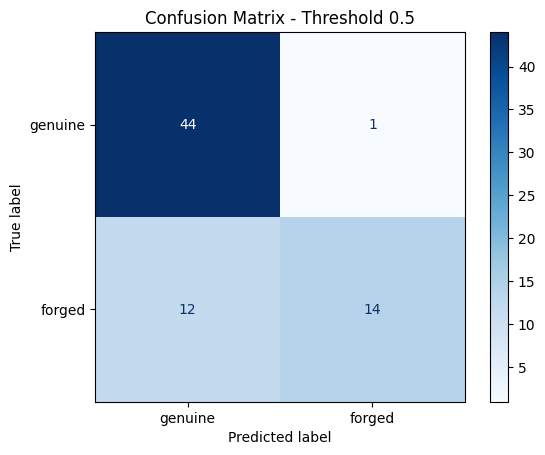

In [9]:
threshold = 0.5

y_pred_05 = (y_prob >= threshold).astype(int)

print(classification_report(y_true, y_pred_05, target_names=["genuine", "forged"]))

cm = confusion_matrix(y_true, y_pred_05)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["genuine", "forged"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Threshold 0.5")
plt.show()

Threshold Sweep

In [10]:
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append(
        {
            "threshold": threshold,
            "accuracy": accuracy,
            "forged_precision": precision,
            "forged_recall": recall,
            "forged_f1": f1,
            "true_genuine": tn,
            "false_forged": fp,
            "missed_forged": fn,
            "true_forged": tp,
        }
    )

df_thresholds = pd.DataFrame(results)

df_thresholds

,threshold,accuracy,forged_precision,forged_recall,forged_f1,true_genuine,false_forged,missed_forged,true_forged
0,0.10,0.830986,0.705882,0.923077,0.800000,35,10,2,24
1,0.15,0.915493,0.857143,0.923077,0.888889,41,4,2,24
2,0.20,0.901408,0.913043,0.807692,0.857143,43,2,5,21
3,0.25,0.873239,0.904762,0.730769,0.808511,43,2,7,19
4,0.30,0.859155,0.900000,0.692308,0.782609,43,2,8,18
5,0.35,0.845070,0.894737,0.653846,0.755556,43,2,9,17
6,0.40,0.816901,0.882353,0.576923,0.697674,43,2,11,15
7,0.45,0.816901,0.933333,0.538462,0.682927,44,1,12,14
8,0.50,0.816901,0.933333,0.538462,0.682927,44,1,12,14
9,0.55,0.788732,0.923077,0.461538,0.615385,44,1,14,12


Best Threshold by Forged F1

In [11]:
best_row = df_thresholds.sort_values("forged_f1", ascending=False).iloc[0]

best_threshold = best_row["threshold"]

print("Best threshold based on forged F1:")
print(best_row)

Best threshold based on forged F1:
threshold            0.150000
accuracy             0.915493
forged_precision     0.857143
forged_recall        0.923077
forged_f1            0.888889
true_genuine        41.000000
false_forged         4.000000
missed_forged        2.000000
true_forged         24.000000
Name: 1, dtype: float64


Plot Threshold Performance

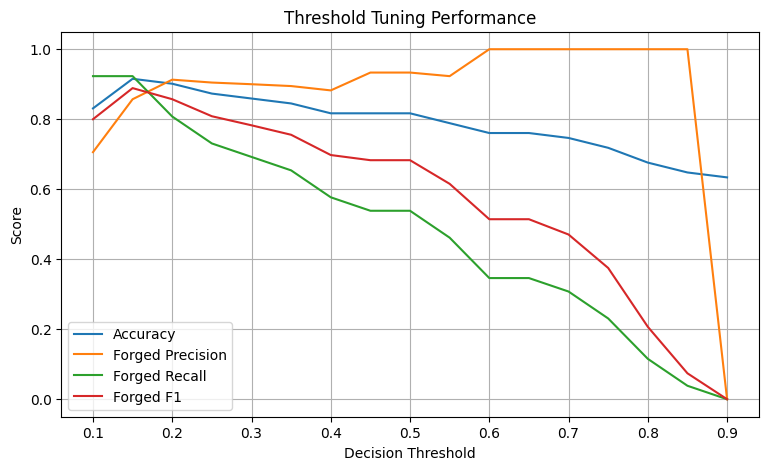

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["accuracy"], label="Accuracy")
plt.plot(
    df_thresholds["threshold"],
    df_thresholds["forged_precision"],
    label="Forged Precision",
)
plt.plot(
    df_thresholds["threshold"], df_thresholds["forged_recall"], label="Forged Recall"
)
plt.plot(df_thresholds["threshold"], df_thresholds["forged_f1"], label="Forged F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Performance")
plt.legend()
plt.grid(True)
plt.show()

Final Evaluation with Best Threshold

Best threshold: 0.15000000000000002
              precision    recall  f1-score   support

     genuine       0.95      0.91      0.93        45
      forged       0.86      0.92      0.89        26

    accuracy                           0.92        71
   macro avg       0.91      0.92      0.91        71
weighted avg       0.92      0.92      0.92        71



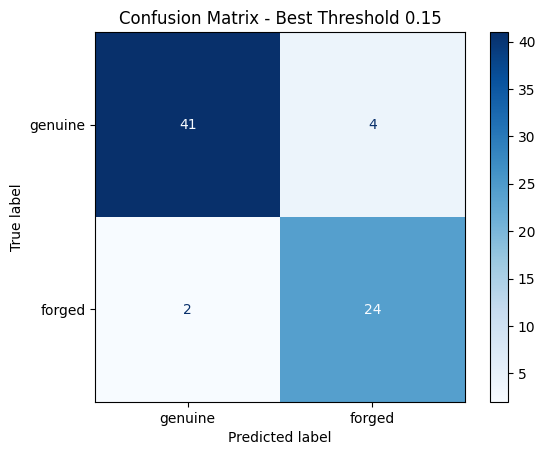

In [13]:
y_pred_best = (y_prob >= best_threshold).astype(int)

print("Best threshold:", best_threshold)

print(classification_report(y_true, y_pred_best, target_names=["genuine", "forged"]))

cm = confusion_matrix(y_true, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["genuine", "forged"])

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Best Threshold {best_threshold:.2f}")
plt.show()

In [14]:
FINAL_MODEL_PATH = "../outputs/models/final_stamp_classifier.keras"

model.save(FINAL_MODEL_PATH)

print("Final model saved:", FINAL_MODEL_PATH)

Final model saved: ../outputs/models/final_stamp_classifier.keras
